In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [16]:
def verifica_nulos(df):
    total_linhas = len(df)
 
    resumo = pd.DataFrame({
        "Tipo"         : df.dtypes,
        "Nulos"        : df.isnull().sum(),
        "Percentual(%)": (df.isnull().sum() / total_linhas * 100).round(2),
        "Preenchidos"  : df.notnull().sum(),
    }).sort_values("Percentual(%)", ascending=False)
 
    colunas_com_nulo = resumo[resumo["Nulos"] > 0]
 
    print(f"\n  Total de colunas com nulos: {len(colunas_com_nulo)} de {df.shape[1]}")
    print(f"  Total de células nulas    : {df.isnull().sum().sum():,}")
    print(f"\n  {'Coluna':<30} {'Nulos':>10} {'Percentual':>12}")
    print(f"  {'-'*54}")
    for col, row in colunas_com_nulo.iterrows():
        print(f"  {col:<30} {int(row['Nulos']):>10,} {row['Percentual(%)']:>11.2f}%")

In [19]:
def histograma_nulos(df: pd.DataFrame) -> None:
    """
    Gera um histograma horizontal com o percentual de valores nulos
    por coluna, ordenado do maior para o menor.
    """
    nulos = (df.isnull().sum() / len(df) * 100).sort_values(ascending=True)
    nulos = nulos[nulos > 0]  # apenas colunas com ao menos 1 nulo

    if nulos.empty:
        print("Nenhum valor nulo encontrado no dataset.")
        return

    cores = ["#d62728" if v > 50 else "#ff7f0e" if v > 20 else "#1f77b4" for v in nulos]

    fig, ax = plt.subplots(figsize=(10, max(4, len(nulos) * 0.4)))

    bars = ax.barh(nulos.index, nulos.values, color=cores, edgecolor="white")

    for bar, valor in zip(bars, nulos.values):
        ax.text(
            bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{valor:.1f}%", va="center", fontsize=8
        )

    ax.set_xlabel("Percentual de Valores Nulos (%)")
    ax.set_title("Valores Nulos por Coluna", fontsize=13, pad=15)
    ax.set_xlim(0, 115)
    ax.axvline(x=20, color="#ff7f0e", linestyle="--", linewidth=0.8, alpha=0.6, label="> 20%")
    ax.axvline(x=50, color="#d62728", linestyle="--", linewidth=0.8, alpha=0.6, label="> 50%")
    ax.legend(fontsize=8, title="Limites de atenção")
    ax.grid(axis="x", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()


In [3]:
# MICRODADOS ENEM 2023    
COLUNAS_ENEM_2023 = ['NU_INSCRICAO','NU_ANO','TP_FAIXA_ETARIA','TP_SEXO','TP_COR_RACA','TP_NACIONALIDADE','TP_ST_CONCLUSAO','TP_ANO_CONCLUIU','TP_ESCOLA','IN_TREINEIRO','NU_ANO','NO_MUNICIPIO_ESC','SG_UF_ESC','TP_DEPENDENCIA_ADM_ESC','TP_LOCALIZACAO_ESC','TP_SIT_FUNC_ESC','TP_STATUS_REDACAO','NU_NOTA_COMP1','NU_NOTA_COMP2','NU_NOTA_COMP3','NU_NOTA_COMP4','NU_NOTA_COMP5','TP_PRESENCA_CN','TP_PRESENCA_CH','TP_PRESENCA_LC','TP_PRESENCA_MT','NU_NOTA_CN','NU_NOTA_CH','NU_NOTA_LC','NU_NOTA_MT','NU_NOTA_REDACAO','CO_PROVA_CN','CO_PROVA_CH','CO_PROVA_LC','CO_PROVA_MT','Q001','Q002','Q003','Q004','Q005','Q006','Q007','Q008','Q009','Q010','Q011','Q012','Q013','Q014','Q015','Q016','Q017','Q018','Q019','Q020','Q021','Q022','Q023','Q024','Q025']

df_enem2023_microdados = pd.read_csv('MICRODADOS_ENEM_2023.csv', sep=';', encoding='latin-1', usecols=COLUNAS_ENEM_2023)

In [ ]:
# Duplicatas MICRODADOS ENEM 2023

qtde = df_enem2023_microdados.duplicated().sum()
print(qtde)

0


In [37]:
# Valores nulos ENEM 2023

verifica_nulos(df_enem2023_microdados)


  Total de colunas com nulos: 20 de 59
  Total de células nulas    : 32,067,789

  Coluna                              Nulos   Percentual
  ------------------------------------------------------
  NO_MUNICIPIO_ESC                2,975,449       75.64%
  TP_DEPENDENCIA_ADM_ESC          2,975,449       75.64%
  SG_UF_ESC                       2,975,449       75.64%
  TP_SIT_FUNC_ESC                 2,975,449       75.64%
  TP_LOCALIZACAO_ESC              2,975,449       75.64%
  NU_NOTA_MT                      1,241,528       31.56%
  NU_NOTA_CN                      1,241,528       31.56%
  CO_PROVA_CN                     1,241,528       31.56%
  CO_PROVA_MT                     1,241,528       31.56%
  CO_PROVA_CH                     1,111,312       28.25%
  CO_PROVA_LC                     1,111,312       28.25%
  NU_NOTA_CH                      1,111,312       28.25%
  NU_NOTA_LC                      1,111,312       28.25%
  NU_NOTA_COMP5                   1,111,312       28.25%
  NU_N

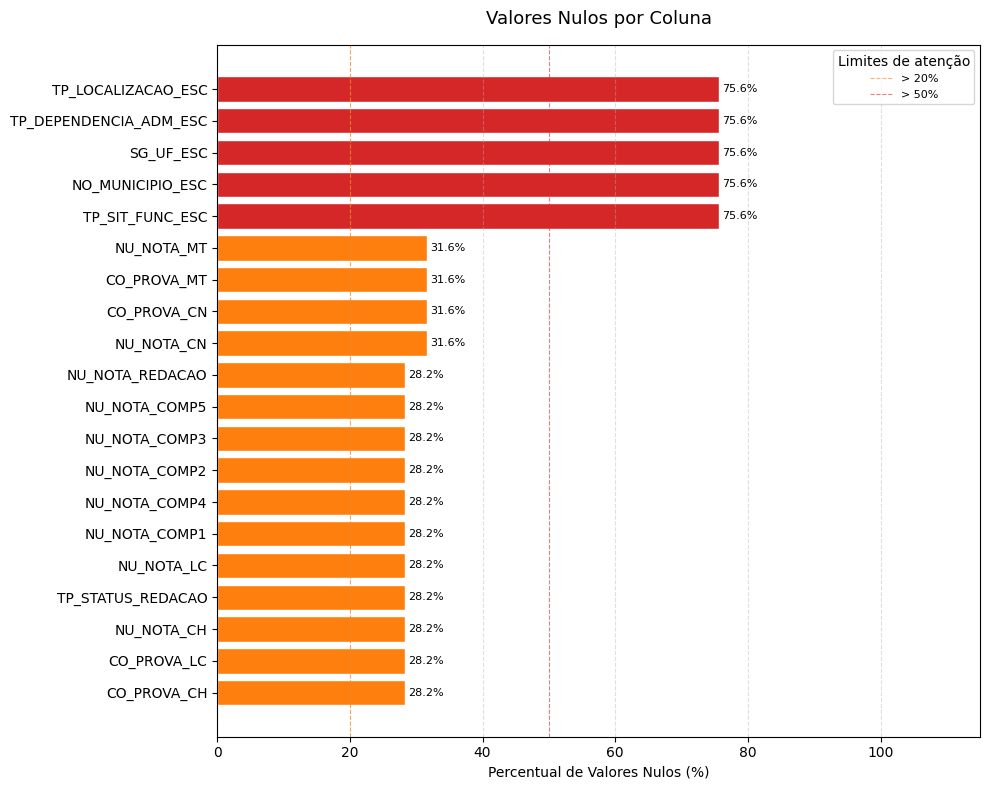

In [42]:
# Histograma nulos ENEM 2023
histograma_nulos(df_enem2023_microdados)

In [7]:
# MICRODADOS ENEM 2024

COLUNAS_PARTICIPANTES_2024 = ['NU_INSCRICAO','NU_ANO','TP_FAIXA_ETARIA','TP_SEXO','TP_COR_RACA','TP_ST_CONCLUSAO','TP_ENSINO','IN_TREINEIRO','NO_MUNICIPIO_PROVA','SG_UF_PROVA','Q001','Q002','Q003','Q004','Q005','Q006','Q007','Q008','Q009','Q010','Q011','Q012','Q013','Q014','Q015','Q016','Q017','Q018','Q019','Q020','Q021','Q022','Q023']
COLUNAS_RESULTADOS_2024 = ['NU_SEQUENCIAL','NU_ANO','CO_ESCOLA','NO_MUNICIPIO_ESC','SG_UF_ESC','TP_DEPENDENCIA_ADM_ESC','TP_LOCALIZACAO_ESC','TP_SIT_FUNC_ESC','TX_GABARITO_CN','TX_GABARITO_CH','TX_GABARITO_LC','TX_GABARITO_MT','TP_STATUS_REDACAO','NU_NOTA_COMP1','NU_NOTA_COMP2','NU_NOTA_COMP3','NU_NOTA_COMP4','NU_NOTA_COMP5','NU_NOTA_REDACAO']

df_enem2024_participantes = pd.read_csv('PARTICIPANTES_2024.csv', sep=';', encoding='latin-1', usecols=COLUNAS_PARTICIPANTES_2024)
df_enem2024_resultados = pd.read_csv('RESULTADOS_2024.csv', sep=';', encoding='latin-1', usecols=COLUNAS_RESULTADOS_2024)

In [ ]:
# Duplicatas PARTICIPANTES ENEM 2024

qtde = df_enem2024_participantes.duplicated().sum()
print(qtde)

0


In [38]:
# Valores nulos PARTICIPANTES ENEM 2024

verifica_nulos(df_enem2024_participantes)


  Total de colunas com nulos: 6 de 33
  Total de células nulas    : 2,787,076

  Coluna                              Nulos   Percentual
  ------------------------------------------------------
  TP_ENSINO                       2,787,062       64.32%
  Q006                                    9        0.00%
  Q008                                    1        0.00%
  Q009                                    1        0.00%
  Q016                                    1        0.00%
  Q019                                    2        0.00%


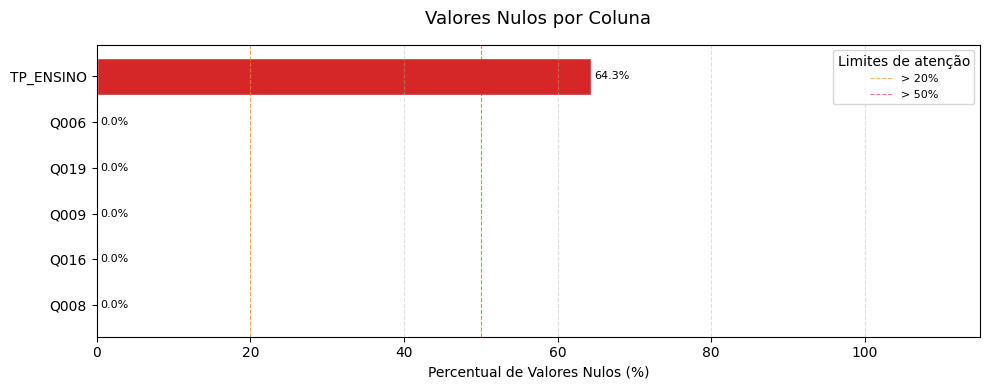

In [43]:
# Histograma nulos PARTICIPANTES ENEM 2024
histograma_nulos(df_enem2024_participantes)

In [52]:
# Duplicatas RESULTADOS ENEM 2024

qtde = df_enem2024_resultados.duplicated().sum()
print(qtde)

0


In [39]:
# Valores nulos RESULTADOS ENEM 2024

verifica_nulos(df_enem2024_resultados)


  Total de colunas com nulos: 17 de 19
  Total de células nulas    : 29,743,709

  Coluna                              Nulos   Percentual
  ------------------------------------------------------
  CO_ESCOLA                       2,767,147       63.86%
  SG_UF_ESC                       2,767,147       63.86%
  NO_MUNICIPIO_ESC                2,767,147       63.86%
  TP_SIT_FUNC_ESC                 2,767,147       63.86%
  TP_LOCALIZACAO_ESC              2,767,147       63.86%
  TP_DEPENDENCIA_ADM_ESC          2,767,147       63.86%
  TX_GABARITO_CN                  1,327,963       30.65%
  TX_GABARITO_MT                  1,327,963       30.65%
  TP_STATUS_REDACAO               1,164,989       26.89%
  TX_GABARITO_LC                  1,164,989       26.89%
  TX_GABARITO_CH                  1,164,989       26.89%
  NU_NOTA_COMP3                   1,164,989       26.89%
  NU_NOTA_COMP4                   1,164,989       26.89%
  NU_NOTA_COMP1                   1,164,989       26.89%
  NU_N

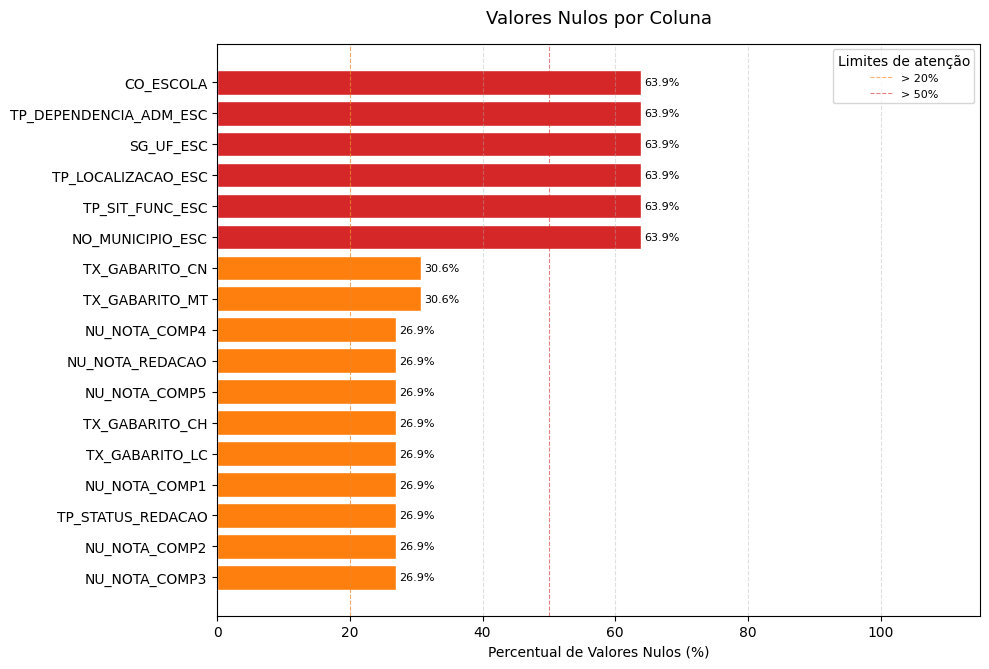

In [44]:
# Histograma nulos RESULTADOS ENEM 2024
histograma_nulos(df_enem2024_resultados)

In [46]:
# TAXA DE RENDIMENTO ESCOLAR 2023 e 2024

COLS_IDENTIF = ["NU_ANO_CENSO","UNIDGEO", "NO_CATEGORIA", "NO_DEPENDENCIA"]

COLS_DESEMPENHO = [
    "1_CAT_FUN",    # Aprovação — Fundamental
    "1_CAT_MED",    # Aprovação — Médio
    "2_CAT_FUN",    # Reprovação — Fundamental
    "2_CAT_MED",    # Reprovação — Médio
    "3_CAT_FUN",    # Abandono — Fundamental
    "3_CAT_MED",    # Abandono — Médio
]

df_tx_rend_2023 = pd.read_excel('tx_rend_brasil_regioes_ufs_2023.xlsx', sheet_name="BRASIL_REGIOES_UFS ", header=8, na_values=["--"])
df_tx_rend_2024 = pd.read_excel('tx_rend_brasil_regioes_ufs_2024.xlsx', sheet_name="BRASIL_REGIOES_UFS ", header=8, na_values=["--"])
df_tx23 = df_tx_rend_2023[COLS_IDENTIF + COLS_DESEMPENHO].copy()
df_tx23 = df_tx23[~df_tx23['UNIDGEO'].isna()]
df_tx24 = df_tx_rend_2024[COLS_IDENTIF + COLS_DESEMPENHO].copy()
df_tx24 = df_tx24[~df_tx24['UNIDGEO'].isna()]

In [47]:
# Duplicatas Taxa de Rendimento 2023

qtde = df_tx23.duplicated().sum()
print(qtde)

0



  Total de colunas com nulos: 6 de 10
  Total de células nulas    : 288

  Coluna                              Nulos   Percentual
  ------------------------------------------------------
  2_CAT_MED                              49        8.35%
  1_CAT_MED                              49        8.35%
  3_CAT_MED                              49        8.35%
  3_CAT_FUN                              47        8.01%
  2_CAT_FUN                              47        8.01%
  1_CAT_FUN                              47        8.01%


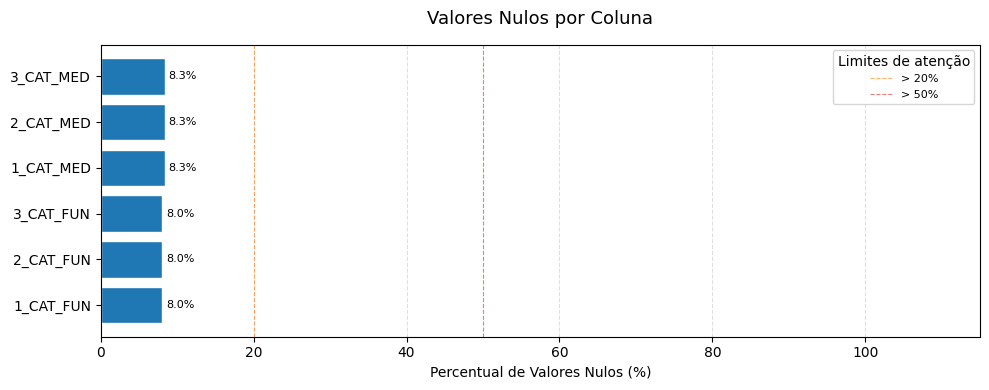

In [48]:
# Valores nulos Taxa de Rendimento 2023

verifica_nulos(df_tx23)
histograma_nulos(df_tx23)

In [49]:
# Duplicatas Taxa de Rendimento 2024

qtde = df_tx24.duplicated().sum()
print(qtde)

0



  Total de colunas com nulos: 6 de 10
  Total de células nulas    : 279

  Coluna                              Nulos   Percentual
  ------------------------------------------------------
  2_CAT_MED                              48        8.18%
  1_CAT_MED                              48        8.18%
  3_CAT_MED                              48        8.18%
  3_CAT_FUN                              45        7.67%
  2_CAT_FUN                              45        7.67%
  1_CAT_FUN                              45        7.67%


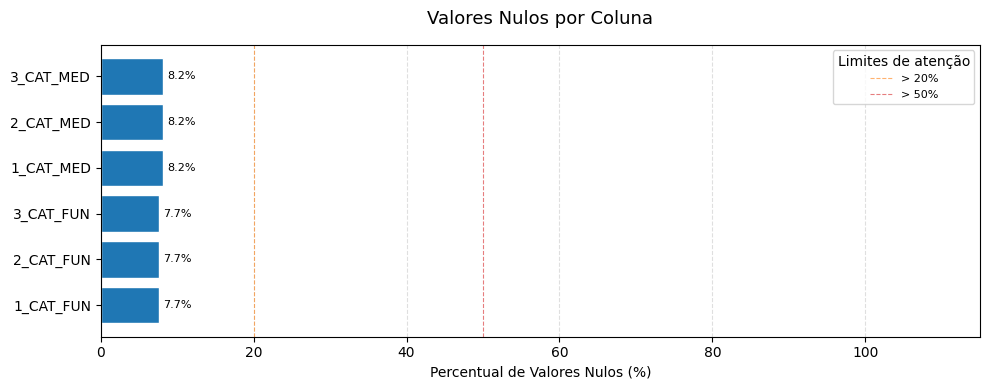

In [50]:
# Valores nulos Taxa de Rendimento 2024

verifica_nulos(df_tx24)
histograma_nulos(df_tx24)

In [53]:
# MICRODADOS SAEB 2023

COLUNAS_SAEB = ['ID_ALUNO','ID_REGIAO','ID_UF','ID_MUNICIPIO','ID_ESCOLA','IN_PUBLICA','ID_LOCALIZACAO','ID_SERIE','IN_SITUACAO_CENSO','PROFICIENCIA_LP_SAEB','PROFICIENCIA_MT_SAEB','IN_ALFABETIZADO','IN_PROFICIENCIA_LP','IN_PROFICIENCIA_MT']

df_ts_aluno_2EF = pd.read_csv('TS_ALUNO_2EF.csv', sep=';', encoding='latin-1', usecols=COLUNAS_SAEB)

In [54]:
# Duplicatas SAEB 2023

qtde = df_ts_aluno_2EF.duplicated().sum()
print(qtde)

0


In [55]:
# Valores nulos SAEB 2023

verifica_nulos(df_ts_aluno_2EF)


  Total de colunas com nulos: 2 de 14
  Total de células nulas    : 16,994

  Coluna                              Nulos   Percentual
  ------------------------------------------------------
  PROFICIENCIA_LP_SAEB                8,542       23.02%
  PROFICIENCIA_MT_SAEB                8,452       22.78%


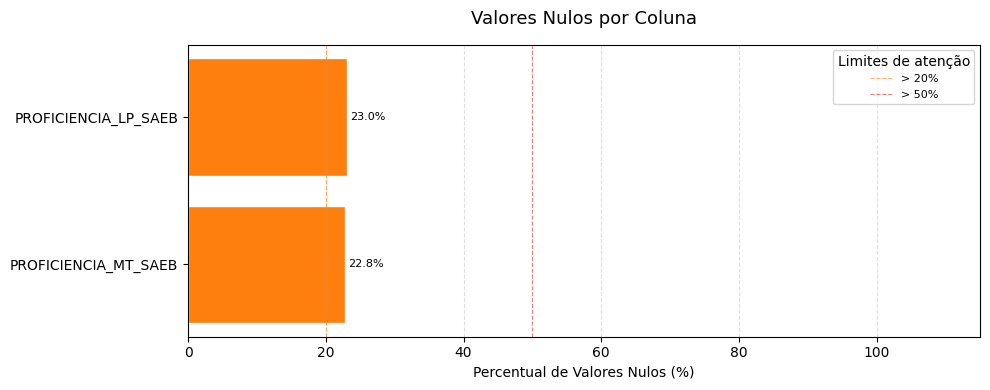

In [46]:
# Histograma nulos SAEB 2023
histograma_nulos(df_ts_aluno_2EF)